# Main Agent Evaluation

Replays every labeled recruiter turn in `sms_conversations.json` through `MainAgent.step()` and scores the predicted action (`continue` / `schedule` / `end`) against the ground-truth label.

**Context reconstruction rule:** for a labeled recruiter turn at index `i` in a conversation, the history passed to the agent is `turns[:i]` (everything strictly *before* that turn). The turn's own text is never given to the agent as input — only its `label` is used as ground truth. The candidate message that triggers the prediction is the last candidate turn inside that history (or `None` for a conversation's very first recruiter turn).

**Eval-only DB seeding:** the labeled dataset's timestamps are all from April 2024, but the live-demo SQLite DB (`data/schedule.db`) is seeded dynamically starting from today. To keep the Scheduling Advisor's tool calls meaningful during evaluation, this notebook seeds a **separate** SQLite DB anchored at `2024-01-01` and points the agent at that instead.

**Non-determinism caveat:** advisors call a real LLM. Exit/Scheduling advisors use temperature 0.0-0.2 to stay close to deterministic, but exact repeatability across runs isn't guaranteed. Re-run this notebook if results look like an outlier.

In [1]:
import json
import sys
from datetime import date, datetime
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "tests" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from app.main import build_main_agent
from app.modules.scheduling_db.schema_migrate import create_and_seed

SOURCE_PATH = PROJECT_ROOT / "sms_conversations.json"
EVAL_DB_PATH = PROJECT_ROOT / "data" / "schedule_eval.db"

with open(SOURCE_PATH, encoding="utf-8") as f:
    conversations = json.load(f)

print(f"Loaded {len(conversations)} conversations")

Loaded 15 conversations


In [2]:
# Seed a separate eval-only DB anchored at the dataset's own date range (2024)
stats = create_and_seed(str(EVAL_DB_PATH), start_date=date(2024, 1, 1), horizon_days=365, seed=7)
print(f"Seeded {stats.rows_inserted} rows covering {stats.start_date} .. {stats.end_date}")

agent = build_main_agent(db_path=str(EVAL_DB_PATH))

Seeded 9396 rows covering 2024-01-01 .. 2024-12-31


In [3]:
def last_candidate_message(history):
    for turn in reversed(history):
        if turn["speaker"] == "candidate":
            return turn["text"]
    return None


records = []
for conv in conversations:
    turns = conv["turns"]
    for i, turn in enumerate(turns):
        if turn["speaker"] != "recruiter" or turn.get("label") is None:
            continue

        history = turns[:i]
        candidate_message = last_candidate_message(history)
        conversation_now = datetime.fromisoformat(turn["timestamp_utc"].replace("Z", "+00:00")).replace(tzinfo=None)

        decision = agent.step(history, candidate_message, conversation_now)

        records.append(
            {
                "conversation_id": conv["conversation_id"],
                "turn_id": turn["turn_id"],
                "y_true": turn["label"],
                "y_pred": decision.action,
                "reply_text": decision.reply_text,
                "meta": decision.meta,
            }
        )

print(f"Scored {len(records)} labeled turns")

Scored 59 labeled turns


Accuracy: 0.627

              precision    recall  f1-score   support

    continue       0.58      0.88      0.70        25
    schedule       0.55      0.32      0.40        19
         end       0.90      0.60      0.72        15

    accuracy                           0.63        59
   macro avg       0.67      0.60      0.61        59
weighted avg       0.65      0.63      0.61        59



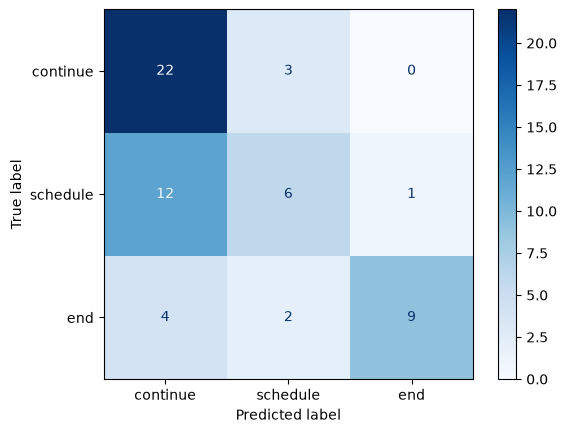

In [4]:
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix

df = pd.DataFrame(records)
labels = ["continue", "schedule", "end"]

accuracy = accuracy_score(df["y_true"], df["y_pred"])
print(f"Accuracy: {accuracy:.3f}\n")
print(classification_report(df["y_true"], df["y_pred"], labels=labels))

cm = confusion_matrix(df["y_true"], df["y_pred"], labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")

In [5]:
# Misclassified rows, for qualitative discussion in the write-up
misclassified = df[df["y_true"] != df["y_pred"]]
print(f"{len(misclassified)} / {len(df)} misclassified\n")
misclassified[["conversation_id", "turn_id", "y_true", "y_pred", "reply_text"]]

22 / 59 misclassified



,conversation_id,turn_id,y_true,y_pred,reply_text
2,1,5,schedule,continue,No worries! What day and time works best for y...
5,2,3,continue,schedule,That's great to hear! Your experience with Dja...
8,2,9,end,continue,Thanks for confirming! Let me check the availa...
12,3,7,end,schedule,Monday at 3 PM works great! I'll confirm that ...
14,4,3,continue,schedule,Great to hear about your experience! Your back...
18,5,3,schedule,continue,That's great to hear! We value backend experie...
21,6,3,schedule,continue,"That's great to hear! With your experience, yo..."
25,7,5,schedule,continue,No problem! How about Wednesday at 2 PM or Thu...
29,8,5,schedule,continue,No problem! Could you let me know your availab...
30,8,7,schedule,end,Thank you for your time! If your availability ...
